In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from numba import prange

/home/noah/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [119]:
# Parameters
N_s   = 30
beta = 1.0
# global_inhibition = 0.2
# width = 0.2
v = 0.5
dt = 0.1
# L = 1000
sigma = 1.5
kappa = 20
u = 8

psi1 = np.pi
gamma1 = 5.0

psi2 = 0
gamma2 = 3.0

psi3 = np.pi * 3/2
gamma3 = 8.0

# targets = np.array([psi1, psi2, psi3])
targets = np.array([psi1, psi2])

# gammas = np.array([gamma1, gamma2, gamma3])
gammas = np.array([gamma1, gamma2])




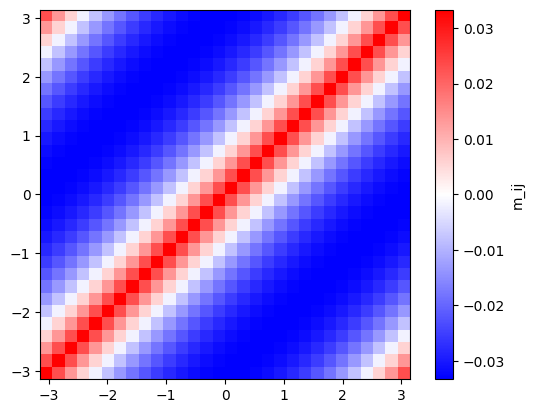

In [120]:
# Node positions and connectivity
#theta = np.array([2*np.pi*i/N_s for i in range(N_s)])
theta = np.linspace(-np.pi, np.pi, N_s, endpoint=False)

M = np.zeros((N_s, N_s))
for i in range(N_s):
    for j in range(N_s):          
        angular_diff = np.abs(wrap_around(theta[i], theta[j]))
        M[i, j] = np.cos(np.pi * np.power((angular_diff/np.pi), v)) * (1/N_s) #abs not right?

plt.imshow(M, extent=[-np.pi, np.pi, -np.pi, np.pi], cmap='bwr',origin='lower')
plt.colorbar(label='m_ij')
plt.show()


In [121]:
#Helper functions
def plot_ring(z, theta, name):
    firing_rate  = z
    theta_closed = np.append(theta, theta[0])
    fr_closed    = np.append(z, z[0])

    r_base = 0
    fig, ax = plt.subplots(figsize=(6, 6))
    #ax.fill_between(theta_closed, r_base, r_base + fr_closed * 0.4, color='blue')
    #ax.plot(theta_closed, r_base + fr_closed * 0.4, color='blue', linewidth=1.5)
    #ax.fill_between(theta_closed, r_base, r_base + fr_closed * 0.4, alpha=0.4, color='blue')
    ax.plot(theta, z, color='blue')

    ax.set_ylim(0, 2.0)
    ax.set_title(f'Firing rate of {name} around the ring')
    plt.tight_layout()
    plt.show()
    

def find_centre_off_mass(weights, angles):
    com = np.zeros(2)
    weighted_sum = np.zeros(2)
    total_weights = 0

    for i in range(len(weights)):
        weighted_sum += np.array([weights[i] * np.cos(angles[i]), weights[i] * np.sin(angles[i])])
        total_weights += weights[i]

    com = weighted_sum/total_weights

    return com

def rand_link_func(y, sigma, inv_sqrt_n):
    out = np.empty_like(y)
    for i in prange(y.size):
        out[i] = np.random.normal(0.0, sigma) * inv_sqrt_n

    return out


def wrap_around(a1, a2):
    return (((a1-a2) + np.pi) % (2*np.pi)) - np.pi


5.0
3.0


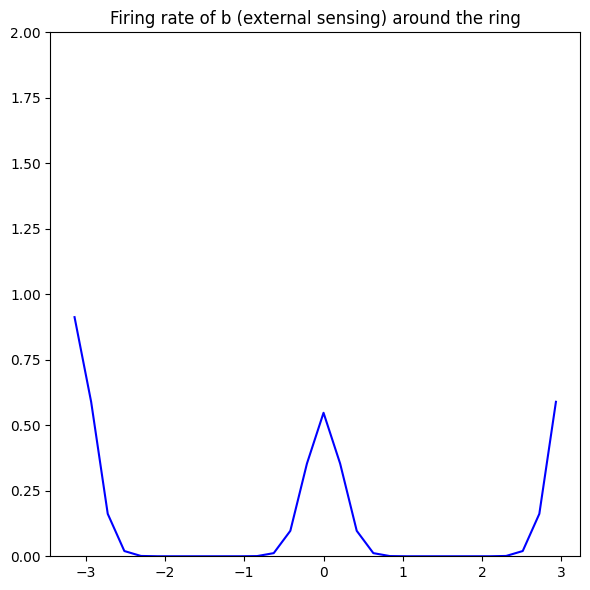

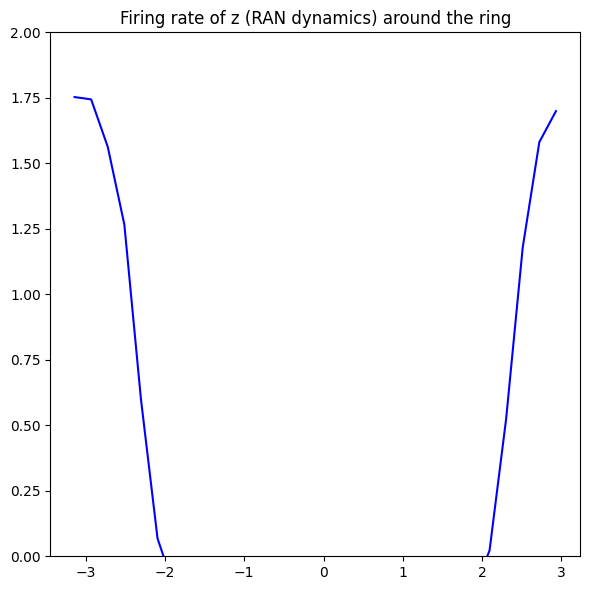

[]

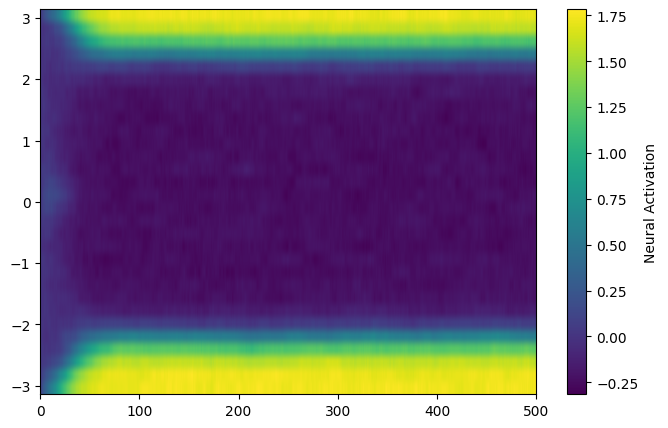

In [122]:
# Static RAN run
z      = np.zeros(N_s)
z_next = np.zeros(N_s)
T      = 500
y      = np.zeros((T, N_s))

b = np.zeros(N_s)

for j in range(len(targets)):
    for i in range(N_s):
        angular_diff = wrap_around(theta[i], targets[j])
        b[i] += np.exp(kappa * (np.cos(angular_diff) - 1.0)) * gammas[j]
    print(gammas[j])

b *= (1/np.sqrt(N_s)) 

for t in range(T):
    # if t % 20 == 0:
    #     print(f"t={t}, max z={z.max():.4f}, min z={z.min():.4f}")

    noise = rand_link_func(y[t], sigma * np.sqrt(dt), 1.0/np.sqrt(N_s))
    z = z + dt * (-z + np.tanh(u * (M @ z) + b - beta) - np.tanh(-beta) + noise) 
    y[t] = z

# print(M@z)
#vel_vec = find_centre_off_mass(z, theta)

plot_ring(b, theta, "b (external sensing)")
plot_ring(z, theta, "z (RAN dynamics)")

plt.figure(figsize=(8,5))
plt.imshow(y.T, aspect='auto', origin='lower', cmap='viridis', extent=[0, T, -np.pi, np.pi])
plt.colorbar(label='Neural Activation')

plt.plot()


In [116]:
# Warm up network to settled bump state before recording
u      = np.zeros(N_s)
z_next = np.zeros(N_s)
b    = np.zeros(N_s)

for _ in range(500):
    h = np.zeros(N_s)
    for i in range(N_s):
        angular_diff = np.arctan2(np.sin(theta[i] - target), np.cos(theta[i] - target))
        h[i] = (b / np.sqrt(2 * np.pi * sigma**2)) * np.exp(-angular_diff**2 / (2 * sigma**2))
    for i in range(N_s):
        excitation_term = 0
        for j in range(N_s):
            excitation_term += M[i][j] * np.tanh(beta * u[j])
        z_next[i] = u[i] + dt * (-u[i] + (1/N_s) * excitation_term - h_b + h[i])
    u[:] = z_next

# Pre-compute all animation frames from settled state
frames = []
for t in range(150):
    # if (t > 60):
    #     moving_target = ((150 - t / 100) % (2 * np.pi))
    # else:
    #     moving_target = (t / 100) % (2 * np.pi)

    h = np.zeros(N_s)
    for i in range(N_s):
        angular_diff = np.arctan2(np.sin(theta[i] - moving_target), np.cos(theta[i] - moving_target))
        h[i] = (b / np.sqrt(2 * np.pi * sigma**2)) * np.exp(-angular_diff**2 / (2 * sigma**2))
    for i in range(N_s):
        excitation_term = 0
        for j in range(N_s):
            excitation_term += M[i][j] * np.tanh(beta * u[j])
        z_next[i] = u[i] + dt * (-u[i] + (1/N_s) * excitation_term - h_b + h[i])
    u[:] = z_next
    frames.append(np.maximum(0, np.tanh(beta * u.copy())))

from matplotlib.animation import PillowWriter
from IPython.display import Image

r_base       = 0.5
theta_closed = np.append(theta, theta[0])

fig, ax = plt.subplots(figsize=(5, 5), subplot_kw={'projection': 'polar'})
fr0  = np.append(frames[0], frames[0][0])
fill = [ax.fill_between(theta_closed, r_base, r_base + fr0 * 0.4, theta=0.4, color='blue')]
line, = ax.plot(theta_closed, r_base + fr0 * 0.4, color='blue', linewidth=1.5)
ax.set_ylim(0, 1.1)
ax.set_yticks([])
ax.set_title('Firing rate around the ring')

writer = PillowWriter(fps=20)
with writer.saving(fig, 'ran_animation.gif', dpi=80):
    for frame_data in frames:
        fill[0].remove()
        fr = np.append(frame_data, frame_data[0])
        fill[0] = ax.fill_between(theta_closed, r_base, r_base + fr * 0.4, theta=0.4, color='blue')
        line.set_ydata(r_base + fr * 0.4)
        writer.grab_frame()

plt.close()
Image('ran_animation.gif')

NameError: name 'target' is not defined